Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 313
Code Title: | Advanced Machine Learning and Deep Learning
2nd Semester | AY 2025-2026
<u>**Hands-on Activity 7.2** | **CNN Architectures from Scratch and Transfer Learning**
**Names** | Jhon Hendricks Bautista <br> Adrian Justin Bulambao
**Section** | CPE32S3
**Date Performed**: | March 19, 2026
**Date Submitted**: | March 23, 2026
**Instructor**: | Engr. Neal Barton James Matira

<hr>


## **Creating VGG-16 from scratch**

#### importing the libraries needed

In [20]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
inputs = Input(shape=(128,128,3))

# Block 1
x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
x = Conv2D(32, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)

# Block 2
x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)

# Block 3
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = Dropout(0.8)(x)
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)

# Block 4
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)

# Block 5
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = Dropout(0.8)(x)
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = GlobalAveragePooling2D()(x)
x = Dense(units = 128, activation ='relu')(x) 
x = Dropout(0.6)(x)

outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 64)        36928     
                                                             

In [2]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dir = r"FastAI_ImageNet_v2\train"
val_dir = r"FastAI_ImageNet_v2\val"

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_dataset = image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_dataset = image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)


Found 9469 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.


In [ ]:
model.compile(optimizer = Adam(learning_rate=1e-4), loss = SparseCategoricalCrossentropy(), metrics = ['accuracy'])

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
]


history_vgg_scratch = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)

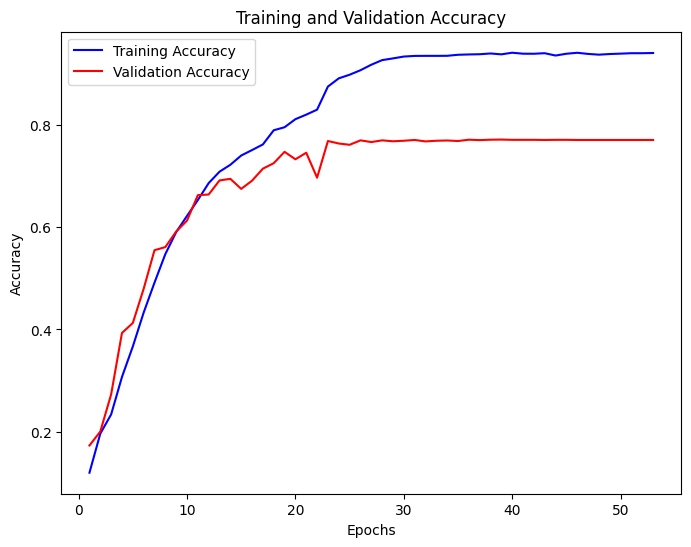

In [7]:
acc = history_vgg_scratch.history['accuracy']
val_acc = history_vgg_scratch.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

246/246 [==============================] - 2s 7ms/step


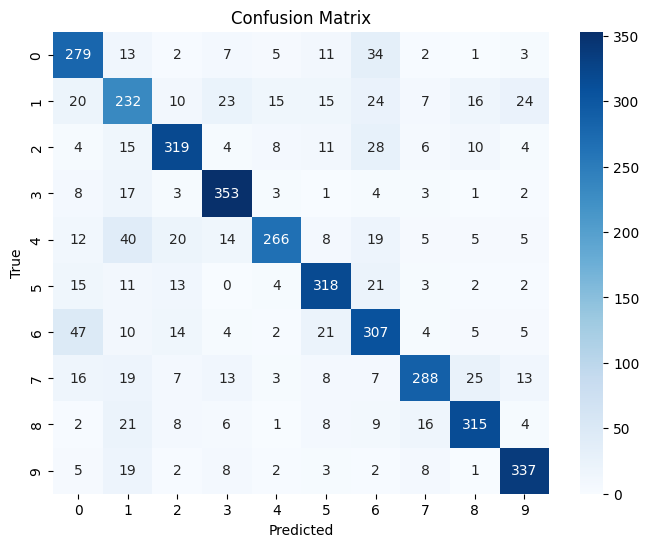

In [8]:
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [9]:
report = classification_report(y_true, y_pred, digits=4)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0     0.6838    0.7815    0.7294       357
           1     0.5844    0.6010    0.5926       386
           2     0.8015    0.7800    0.7906       409
           3     0.8171    0.8937    0.8537       395
           4     0.8608    0.6751    0.7568       394
           5     0.7871    0.8175    0.8020       389
           6     0.6747    0.7327    0.7025       419
           7     0.8421    0.7218    0.7773       399
           8     0.8268    0.8077    0.8171       390
           9     0.8446    0.8708    0.8575       387

    accuracy                         0.7679      3925
   macro avg     0.7723    0.7682    0.7680      3925
weighted avg     0.7729    0.7679    0.7681      3925



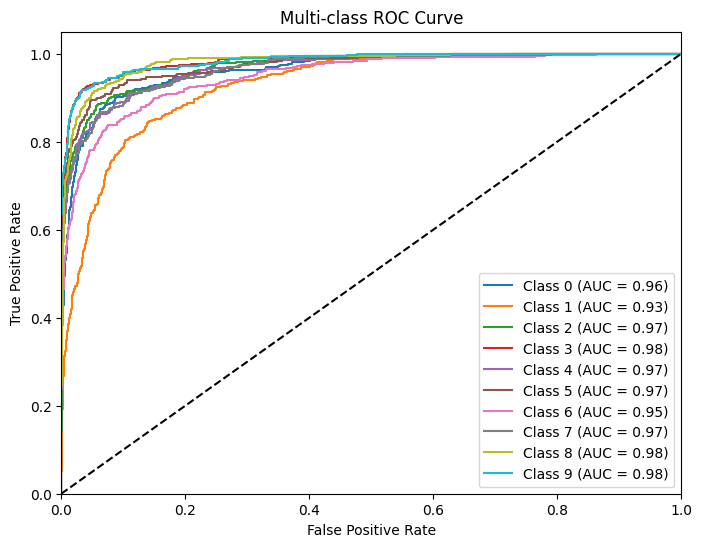

In [10]:
num_classes = y_pred_probs.shape[1]
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes)

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Analysis

The model was not able to reach a 95% accuracy, this might be because of the weights that not set in the model there are no pre-trained weights so it had trouble in learning the dataset properly.<hr>

<br>
<br>
<br>

## **Base VGG16**

In [ ]:
from tensorflow.keras.applications import VGG16

base_model1 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model1.layers[:-1]:
    layer.trainable = False

for layer in base_model1.layers[-1:]:
    layer.trainable = True

x = base_model1.output

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.8)(x)

outputs = Dense(10, activation='softmax')(x)

model2 = Model(inputs=base_model1.input, outputs=outputs)

model2.summary()

Model: "model_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_14 (InputLayer)       [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0  

In [39]:
model2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_vgg_base = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50
)

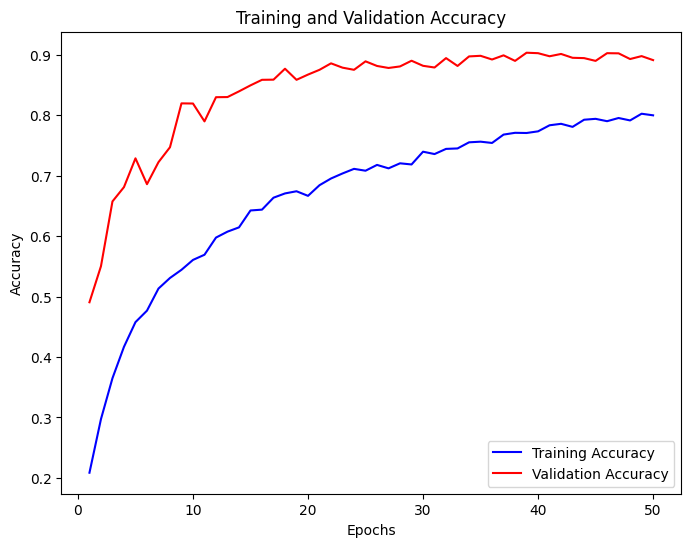

In [37]:
acc2 = history_vgg_base.history['accuracy']
val_acc2 = history_vgg_base.history['val_accuracy']
epochs = range(1, len(acc2) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, acc2, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc2, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

246/246 [==============================] - 4s 16ms/step


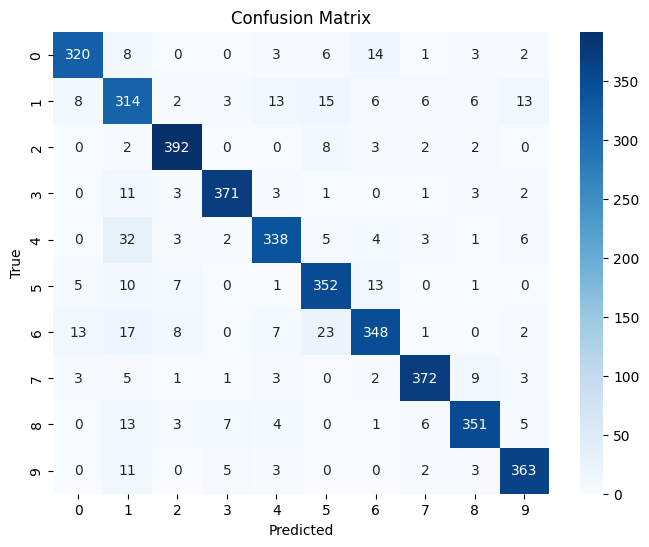

In [41]:
y_true2 = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs2 = model2.predict(val_dataset)
y_pred2 = np.argmax(y_pred_probs2, axis=1)

cm = confusion_matrix(y_true2, y_pred2)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [42]:
report2 = classification_report(y_true2, y_pred2, digits=4)
print("Classification Report:\n", report2)

Classification Report:
               precision    recall  f1-score   support

           0     0.9169    0.8964    0.9065       357
           1     0.7423    0.8135    0.7763       386
           2     0.9356    0.9584    0.9469       409
           3     0.9537    0.9392    0.9464       395
           4     0.9013    0.8579    0.8791       394
           5     0.8585    0.9049    0.8811       389
           6     0.8900    0.8305    0.8593       419
           7     0.9442    0.9323    0.9382       399
           8     0.9261    0.9000    0.9129       390
           9     0.9167    0.9380    0.9272       387

    accuracy                         0.8971      3925
   macro avg     0.8985    0.8971    0.8974      3925
weighted avg     0.8988    0.8971    0.8975      3925



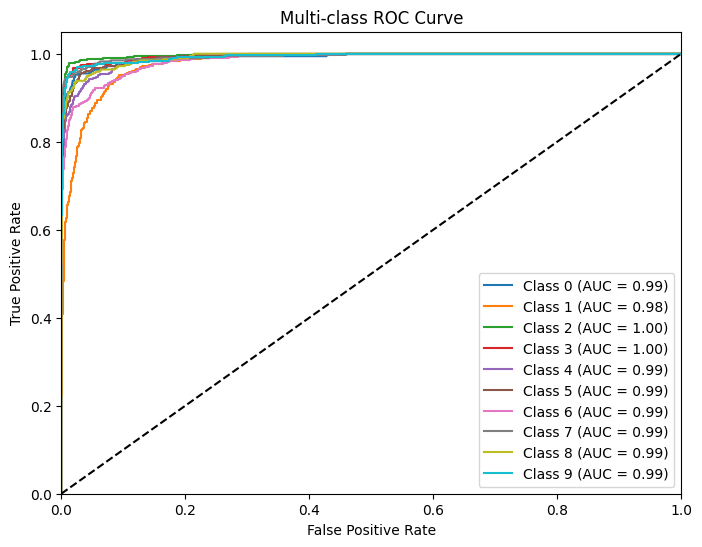

In [43]:
num_classes = y_pred_probs2.shape[1]
y_true_onehot2 = tf.keras.utils.to_categorical(y_true, num_classes)

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_onehot2[:, i], y_pred_probs2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Analysis:

Even though it has a the imagenet weight the base model was also not able to reach a 95% accuracy, changing the parameters of the model were also done, like unfreezing certain layers to allow those layer to be trainable, and changing the learning rate. It performed better than the one from scratch as it have the imagenet weight in it, but was still not able to reach a 95% accuracy.

<hr>

<br>
<br>
<br>

## **Creating MobileNetV2 from scratch**

In [ ]:
inputs = Input(shape=(128,128,3))

# Block 1
x = Conv2D(32, (3,3), strides=2, padding='same', use_bias=False)(inputs)
x = BatchNormalization()(x)
x = ReLU(6.)(x)

# Block 2
x1 = Conv2D(32, (1,1), padding='same', use_bias=False)(x)
x1 = BatchNormalization()(x1)
x1 = ReLU(6.)(x1)

x1 = DepthwiseConv2D((3,3), padding='same', use_bias=False)(x1)
x1 = BatchNormalization()(x1)
x1 = ReLU(6.)(x1)

x1 = Conv2D(32, (1,1), padding='same', use_bias=False)(x1)
x1 = BatchNormalization()(x1)

x = Add()([x, x1])

# Block 3
x = Conv2D(64, (1,1), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = ReLU(6.)(x)

x = DepthwiseConv2D((3,3), strides=2, padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = ReLU(6.)(x)

x = Conv2D(64, (1,1), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)

# Block 4
x1 = Conv2D(64, (1,1), padding='same', use_bias=False)(x)
x1 = BatchNormalization()(x1)
x1 = ReLU(6.)(x1)

x1 = DepthwiseConv2D((3,3), padding='same', use_bias=False)(x1)
x1 = BatchNormalization()(x1)
x1 = ReLU(6.)(x1)

x1 = Conv2D(64, (1,1), padding='same', use_bias=False)(x1)
x1 = BatchNormalization()(x1)

x = Add()([x, x1])

# Block 5 
x = Conv2D(128, (1,1), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = ReLU(6.)(x)

x = DepthwiseConv2D((3,3), strides=2, padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = ReLU(6.)(x)

x = Conv2D(128, (1,1), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)

# Block 6
x1 = Conv2D(128, (1,1), padding='same', use_bias=False)(x)
x1 = BatchNormalization()(x1)
x1 = ReLU(6.)(x1)

x1 = DepthwiseConv2D((3,3), padding='same', use_bias=False)(x1)
x1 = BatchNormalization()(x1)
x1 = ReLU(6.)(x1)

x1 = Conv2D(128, (1,1), padding='same', use_bias=False)(x1)
x1 = BatchNormalization()(x1)

x = Add()([x, x1])

# Block 7
x = Conv2D(256, (1,1), padding='same', use_bias=False)(x)
x = BatchNormalization()(x)
x = ReLU(6.)(x)

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.8)(x)

outputs = Dense(10, activation='softmax')(x)

model3 = Model(inputs, outputs)
model3.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_24 (Conv2D)             (None, 64, 64, 32)   864         ['input_3[0][0]']                
                                                                                                  
 batch_normalization_34 (BatchN  (None, 64, 64, 32)  128         ['conv2d_24[0][0]']              
 ormalization)                                                                                    
                                                                                            

In [15]:
model3.compile(optimizer = Adam(learning_rate=1e-4), loss = SparseCategoricalCrossentropy(), metrics = ['accuracy'])

In [ ]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]


history_mobilenet_scratch = model3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)

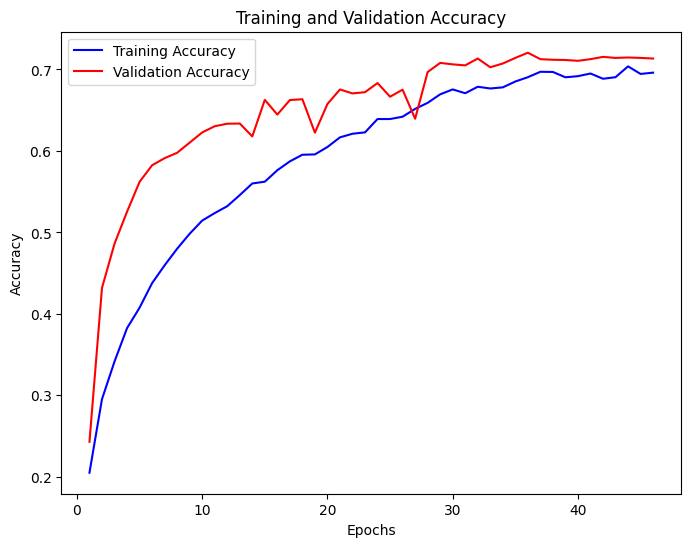

In [17]:
acc3 = history_mobilenet_scratch.history['accuracy']
val_acc3 = history_mobilenet_scratch.history['val_accuracy']
epochs = range(1, len(acc3) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, acc3, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc3, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

246/246 [==============================] - 1s 4ms/step


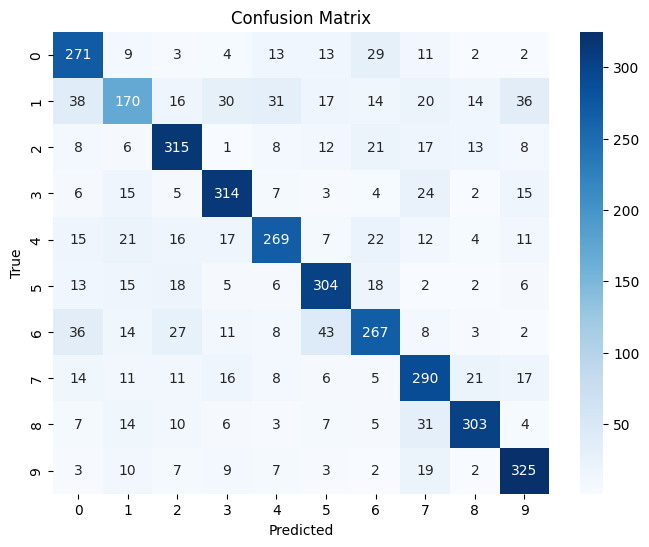

In [18]:
y_true3 = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs3 = model3.predict(val_dataset)
y_pred3 = np.argmax(y_pred_probs3, axis=1)

cm = confusion_matrix(y_true3, y_pred3)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Analysis

The model has a higher validation accuracy than the training accuracy. This might be that for the model the validation dataset was much better than the training dataset. Other reason could be the batch normalization and the dropout of 0.8 which affected the training accuracy.

<hr>
<br>
<br>
<br>

## **Base MobilenetV2**

In [24]:
base_model2 = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

inputs = base_model2.input

x = base_model2.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(10, activation='softmax')(x)

model4 = Model(inputs, outputs)
model4.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_5[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][0]']         

In [25]:
model4.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_mobilenet_base = model4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

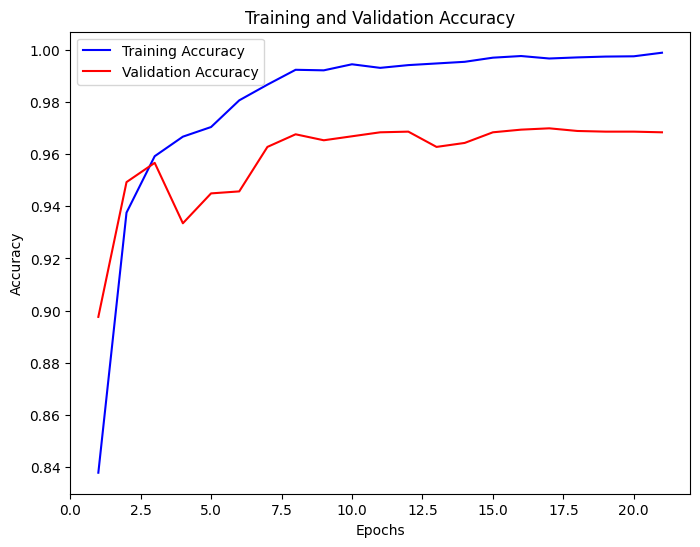

In [28]:
acc4 = history_mobilenet_base.history['accuracy']
val_acc4 = history_mobilenet_base.history['val_accuracy']
epochs = range(1, len(acc4) + 1)

plt.figure(figsize=(8,6))
plt.plot(epochs, acc4, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc4, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

246/246 [==============================] - 2s 7ms/step


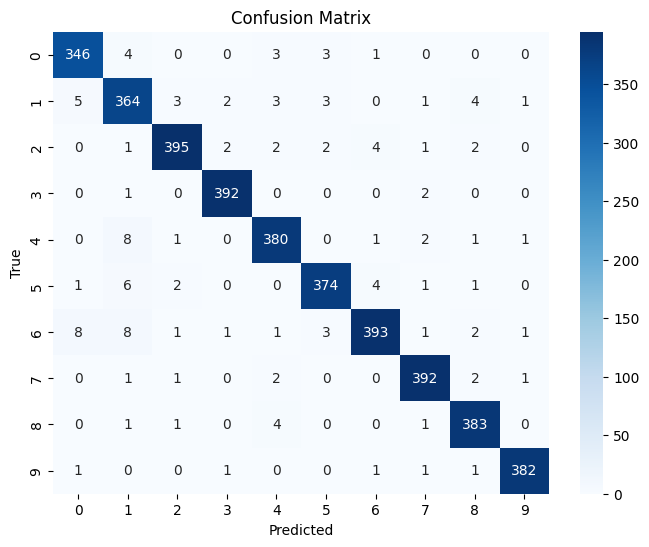

In [29]:
y_true4 = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs4 = model4.predict(val_dataset)
y_pred4 = np.argmax(y_pred_probs4, axis=1)

cm = confusion_matrix(y_true4, y_pred4)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [30]:
report = classification_report(y_true4, y_pred4, digits=4)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0     0.9584    0.9692    0.9638       357
           1     0.9239    0.9430    0.9333       386
           2     0.9777    0.9658    0.9717       409
           3     0.9849    0.9924    0.9887       395
           4     0.9620    0.9645    0.9632       394
           5     0.9714    0.9614    0.9664       389
           6     0.9728    0.9379    0.9550       419
           7     0.9751    0.9825    0.9788       399
           8     0.9672    0.9821    0.9746       390
           9     0.9896    0.9871    0.9884       387

    accuracy                         0.9684      3925
   macro avg     0.9683    0.9686    0.9684      3925
weighted avg     0.9685    0.9684    0.9684      3925



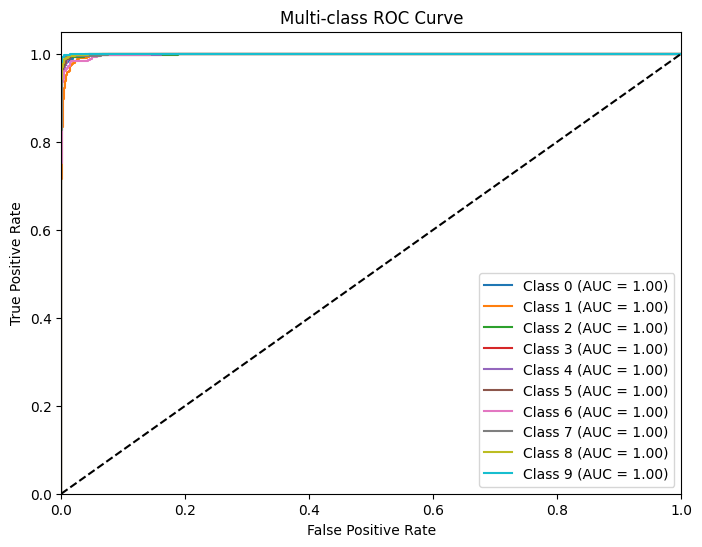

In [32]:
num_classes = y_pred_probs4.shape[1]
y_true_onehot4 = tf.keras.utils.to_categorical(y_true4, num_classes)

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_onehot4[:, i], y_pred_probs4[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Analysis:


The model was able to reach a 96% accuracy on the validation. The curves of the training and validation were close to one another, which indicates that there were no signs of overfitting and the model was able to converge well and learn the patterns of the dataset.
<hr>

<br>
<br>
<br>
<br>

## **Conclusion**



From this activity, it can be seen that the performance of the model is based on the architecture and the pre-trained weights. Building VGG16 from scratch and using a pre-trained VGG16 with ImageNet weights both resulted in poor accuracy, but the differences were noticeable, meaning that the ImageNet weights for the model helped in generalizing. The same applies to MobileNetV2 trained from scratch without pre-trained weights. However, the pre-trained MobileNetV2 with ImageNet weights had good accuracy, showing that for the given dataset, this is the model to be used. This also shows that the efficient architecture of MobileNetV2 is better than the more complex architecture of VGG16.